In [1]:
import arviz as az
import jax
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import pandas as pd
from jax import numpy as jnp
from numpyro import distributions as dist
from sklearn.model_selection import TimeSeriesSplit

from src.data_loading import load_data
from src.modeling.ensemble import DefaultEnsemble
from src.modeling.metrics import summarize
from src.modeling.multivariate import LakeMVT
from src.modeling.var_models import VAR, VARX
from src.preprocessing import XArrayStandardScaler

numpyro.set_host_device_count(4)
numpyro.set_platform("cpu")

In [2]:
rnbs_data = load_data("rnbs")

splitter = TimeSeriesSplit(n_splits=5, test_size=13, gap=0)
cv_splits = list(splitter.split(rnbs_data))

months = jnp.array(rnbs_data.indexes["Date"].month)

In [3]:
def VARModel(y, y_index, lags, future=0, **kwargs):
        """
        Autoregressive process.
        Args:
            y: the time series to fit
            y_index: the datetime index used for getting the month
            lags: A dictionary indicating which covariates have which lags
            future: How many periods to run into the future.

        Returns:
            None - samples

        """
        global_mu = numpyro.sample("global_mu", dist.Normal(0, 1))
        nu = numpyro.sample("nu", dist.InverseGamma(1, 1))

        ar_lag = max_lag = lags.get("y")

        # static priors
        theta = numpyro.sample("theta", dist.InverseGamma(1, 0.1), sample_shape=(4,))

        with numpyro.plate("lakes", size=4):
            with numpyro.plate("other_lake", size=4):
                with numpyro.plate("ar_terms", size=ar_lag):
                    ar_alpha = numpyro.sample("ar_alpha", dist.Laplace(0, 0.5))

            with numpyro.plate("months", size=12):
                intercept = numpyro.sample("intercept", dist.Normal(global_mu, 1))

        # t_nu = numpyro.sample("t_nu", dist.HalfNormal(10))
        l_omega = numpyro.sample("corr", dist.LKJCholesky(4, concentration=0.5))
        sigma = jnp.sqrt(theta)
        L_Omega = sigma[..., None] * l_omega

        def transition_fn(carry, covars):
            prev_y = carry
            month_t = covars

            # final answer
            m_t = jnp.zeros((4,))

            # get the effect of the lagged values
            y_lag = lags.get("y")
            for t in range(y_lag):
                m_t += jnp.matmul(ar_alpha[t], carry[t, :])

            m_t += intercept[month_t, :]
            y_t = numpyro.sample(
                "y", dist.MultivariateStudentT(df=nu, loc=m_t, scale_tril=L_Omega)
            )

            if ar_lag > 1:
                new_vals = jnp.append(prev_y[1:], y_t.reshape(1, -1), axis=0)
            else:
                new_vals = y_t.reshape(1, -1)
            return new_vals, y_t

        prev = y[:max_lag][-ar_lag:]
        # need to subtract one because indexing starts at 0.
        months = jnp.array(y_index.month - 1)
        initial_values = prev

        if future > 0:
            y_fit = y[:-future]
        else:
            y_fit = y

        with numpyro.handlers.condition(data={"y": y_fit[max_lag:]}):
            _, ys = scan(transition_fn, initial_values, months[max_lag:])

        if future > 0:
            numpyro.deterministic("y_forecast", ys[-future:])

In [4]:
results = []
model_traces = []
for train_idx, val_idx in cv_splits:
    scaler = XArrayStandardScaler()
    train_y = jnp.array(scaler.fit_transform(rnbs_data[train_idx]))
    val_y = jnp.array(scaler.transform(rnbs_data[val_idx]))
    month_vals = months[train_idx]

    break
    # mcmc = numpyro.infer.MCMC(
    #     numpyro.infer.NUTS(mvn_model), num_samples=1000, num_warmup=1000, num_chains=4
    # )
    # rng_key = jax.random.key(128781)
    # mcmc.run(rng_key, month=month_vals, y=train_y)

    # model_traces.append(az.from_numpyro(mcmc))

    # samples = mcmc.get_samples()
    # predict_fn = numpyro.infer.Predictive(
    #     mvn_model, posterior_samples=samples, return_sites=["y_hat"]
    # )
    # new_key = jax.random.key(92845)
    # out = predict_fn(new_key, month=months[val_idx])["y_hat"]
    # preds = out.mean(axis=0)

    # cols = rnbs_data.columns

def rmse(pred, true):
    return jnp.sqrt(jnp.mean((pred - true) ** 2, axis=0))



In [ ]:
mod2 = VARX({"y": 2}, num_chains=4, num_samples=500, num_warmup=1000)
mod2.fit(scaler.transform(rnbs_data[train_idx]), rnbs_data[train_idx].indexes["Date"])


  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

/home/mcanearm/miniforge3/envs/nbs_env/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


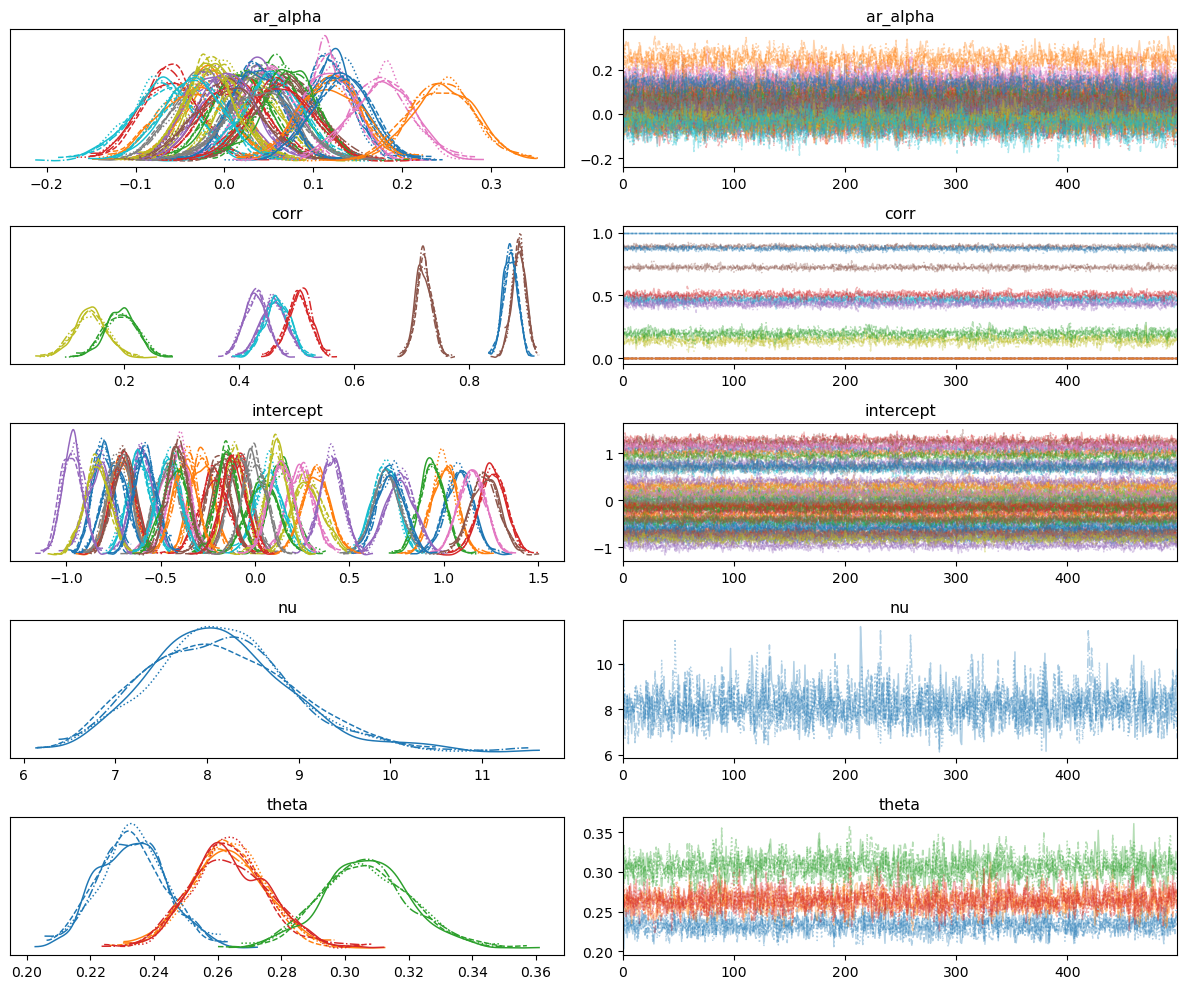

In [7]:
az.plot_trace(mod2.trace)
plt.tight_layout()

In [ ]:
# preds2 = mod2.predict(None, scaler.transform(rnbs_data[val_idx]), forecast_steps=13)

key = jax.random.PRNGKey(1234)
y_index = rnbs_data[:val_idx.max()].indexes["Date"]
validation_set = jnp.array(scaler.transform(rnbs_data[:val_idx.max()]))
# mod2.predictive_fn(key, rnbs_data[val_idx], rnbs_data[val_idx], forecast_steps=13, lags={"y": 2})

preds = mod2.predictive_fn(key, y=validation_set, y_index=y_index, future=13, lags={"y": 2})
# preds = mod2.predict(None, scaler.transform(rnbs_data[:val_idx.max()]), forecast_steps=13)

(2000, 13, 4)

In [ ]:
rmse(preds["y_forecast"].mean(axis=0), val_y)

Array([0.3631934, 0.7206345, 0.7872258, 0.8944298], dtype=float32)